In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("avikpaul4u/vehicle-loan-default-prediction")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\user\.cache\kagglehub\datasets\avikpaul4u\vehicle-loan-default-prediction\versions\4


In [3]:
train_path = path + "/train.csv"
test_path = path + "/test.csv"
import pandas as pd
train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

In [4]:
import matplotlib.pyplot as plt
from plotly import tools
import plotly.offline as py
import plotly.figure_factory as ff
py.init_notebook_mode(connected=True)
import plotly.graph_objs as go
import plotly.express as px
from plotly.subplots import make_subplots

import seaborn as sns
import numpy as np

In [5]:
df = pd.concat([train, test])

In [6]:
print(f"Shape of train: {train.shape}")
print(f"Shape of test: {test.shape}")

Shape of train: (233154, 41)
Shape of test: (112392, 40)


In [7]:
train.shape[0] / test.shape[0]

2.0744714926329277

In [8]:
train.isna().sum()

UNIQUEID                                  0
DISBURSED_AMOUNT                          0
ASSET_COST                                0
LTV                                       0
BRANCH_ID                                 0
SUPPLIER_ID                               0
MANUFACTURER_ID                           0
CURRENT_PINCODE_ID                        0
DATE_OF_BIRTH                             0
EMPLOYMENT_TYPE                        7661
DISBURSAL_DATE                            0
STATE_ID                                  0
EMPLOYEE_CODE_ID                          0
MOBILENO_AVL_FLAG                         0
AADHAR_FLAG                               0
PAN_FLAG                                  0
VOTERID_FLAG                              0
DRIVING_FLAG                              0
PASSPORT_FLAG                             0
PERFORM_CNS_SCORE                         0
PERFORM_CNS_SCORE_DESCRIPTION             0
PRI_NO_OF_ACCTS                           0
PRI_ACTIVE_ACCTS                

In [9]:
train.drop_duplicates(inplace=True)

In [10]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 233154 entries, 0 to 233153
Data columns (total 41 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   UNIQUEID                             233154 non-null  int64  
 1   DISBURSED_AMOUNT                     233154 non-null  int64  
 2   ASSET_COST                           233154 non-null  int64  
 3   LTV                                  233154 non-null  float64
 4   BRANCH_ID                            233154 non-null  int64  
 5   SUPPLIER_ID                          233154 non-null  int64  
 6   MANUFACTURER_ID                      233154 non-null  int64  
 7   CURRENT_PINCODE_ID                   233154 non-null  int64  
 8   DATE_OF_BIRTH                        233154 non-null  object 
 9   EMPLOYMENT_TYPE                      225493 non-null  object 
 10  DISBURSAL_DATE                       233154 non-null  object 
 11  STATE_ID     

In [11]:
data_type = {}
for col in train.columns:
    if train[col].dtype in data_type:
        data_type[train[col].dtype] += 1
    else:
        data_type[train[col].dtype] = 1

data_type

{dtype('int64'): 34, dtype('float64'): 1, dtype('O'): 6}

In [12]:
print(list(train.columns))

['UNIQUEID', 'DISBURSED_AMOUNT', 'ASSET_COST', 'LTV', 'BRANCH_ID', 'SUPPLIER_ID', 'MANUFACTURER_ID', 'CURRENT_PINCODE_ID', 'DATE_OF_BIRTH', 'EMPLOYMENT_TYPE', 'DISBURSAL_DATE', 'STATE_ID', 'EMPLOYEE_CODE_ID', 'MOBILENO_AVL_FLAG', 'AADHAR_FLAG', 'PAN_FLAG', 'VOTERID_FLAG', 'DRIVING_FLAG', 'PASSPORT_FLAG', 'PERFORM_CNS_SCORE', 'PERFORM_CNS_SCORE_DESCRIPTION', 'PRI_NO_OF_ACCTS', 'PRI_ACTIVE_ACCTS', 'PRI_OVERDUE_ACCTS', 'PRI_CURRENT_BALANCE', 'PRI_SANCTIONED_AMOUNT', 'PRI_DISBURSED_AMOUNT', 'SEC_NO_OF_ACCTS', 'SEC_ACTIVE_ACCTS', 'SEC_OVERDUE_ACCTS', 'SEC_CURRENT_BALANCE', 'SEC_SANCTIONED_AMOUNT', 'SEC_DISBURSED_AMOUNT', 'PRIMARY_INSTAL_AMT', 'SEC_INSTAL_AMT', 'NEW_ACCTS_IN_LAST_SIX_MONTHS', 'DELINQUENT_ACCTS_IN_LAST_SIX_MONTHS', 'AVERAGE_ACCT_AGE', 'CREDIT_HISTORY_LENGTH', 'NO_OF_INQUIRIES', 'LOAN_DEFAULT']


In [13]:
object_cols = []
for col in train.columns:
    if train[col].dtype == 'object':
        object_cols.append(col)

object_cols

['DATE_OF_BIRTH',
 'EMPLOYMENT_TYPE',
 'DISBURSAL_DATE',
 'PERFORM_CNS_SCORE_DESCRIPTION',
 'AVERAGE_ACCT_AGE',
 'CREDIT_HISTORY_LENGTH']

In [14]:
train['PERFORM_CNS_SCORE_DESCRIPTION'].value_counts()

PERFORM_CNS_SCORE_DESCRIPTION
No Bureau History Available                                116950
C-Very Low Risk                                             16045
A-Very Low Risk                                             14124
D-Very Low Risk                                             11358
B-Very Low Risk                                              9201
M-Very High Risk                                             8776
F-Low Risk                                                   8485
K-High Risk                                                  8277
H-Medium Risk                                                6855
E-Low Risk                                                   5821
I-Medium Risk                                                5557
G-Low Risk                                                   3988
Not Scored: Sufficient History Not Available                 3765
J-High Risk                                                  3748
Not Scored: Not Enough Info available on the c

In [15]:
train['EMPLOYMENT_TYPE'].value_counts()

EMPLOYMENT_TYPE
Self employed    127635
Salaried          97858
Name: count, dtype: int64

In [16]:
train['CREDIT_HISTORY_LENGTH'].value_counts()

CREDIT_HISTORY_LENGTH
0yrs 0mon      119127
0yrs 6mon        4761
2yrs 1mon        4745
0yrs 7mon        4017
2yrs 0mon        3833
                ...  
23yrs 4mon          1
25yrs 11mon         1
23yrs 1mon          1
21yrs 2mon          1
22yrs 10mon         1
Name: count, Length: 294, dtype: int64

In [17]:
train.groupby('LOAN_DEFAULT')['UNIQUEID'].count()

LOAN_DEFAULT
0    182543
1     50611
Name: UNIQUEID, dtype: int64

In [18]:
train.EMPLOYMENT_TYPE.fillna('Missing', inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_20456\2217623196.py:1: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [19]:
train.EMPLOYMENT_TYPE.value_counts()

EMPLOYMENT_TYPE
Self employed    127635
Salaried          97858
Missing            7661
Name: count, dtype: int64

In [20]:
train.isna().sum()

UNIQUEID                               0
DISBURSED_AMOUNT                       0
ASSET_COST                             0
LTV                                    0
BRANCH_ID                              0
SUPPLIER_ID                            0
MANUFACTURER_ID                        0
CURRENT_PINCODE_ID                     0
DATE_OF_BIRTH                          0
EMPLOYMENT_TYPE                        0
DISBURSAL_DATE                         0
STATE_ID                               0
EMPLOYEE_CODE_ID                       0
MOBILENO_AVL_FLAG                      0
AADHAR_FLAG                            0
PAN_FLAG                               0
VOTERID_FLAG                           0
DRIVING_FLAG                           0
PASSPORT_FLAG                          0
PERFORM_CNS_SCORE                      0
PERFORM_CNS_SCORE_DESCRIPTION          0
PRI_NO_OF_ACCTS                        0
PRI_ACTIVE_ACCTS                       0
PRI_OVERDUE_ACCTS                      0
PRI_CURRENT_BALA

In [21]:
train['CREDIT_HISTORY_LENGTH'].value_counts()

CREDIT_HISTORY_LENGTH
0yrs 0mon      119127
0yrs 6mon        4761
2yrs 1mon        4745
0yrs 7mon        4017
2yrs 0mon        3833
                ...  
23yrs 4mon          1
25yrs 11mon         1
23yrs 1mon          1
21yrs 2mon          1
22yrs 10mon         1
Name: count, Length: 294, dtype: int64

In [22]:
date_cols = ['DATE_OF_BIRTH', 'DISBURSAL_DATE']

In [23]:
duration_cols = ['AVERAGE_ACCT_AGE', 'CREDIT_HISTORY_LENGTH']

In [24]:
train[duration_cols]

,AVERAGE_ACCT_AGE,CREDIT_HISTORY_LENGTH
0,0yrs 0mon,0yrs 0mon
1,1yrs 11mon,1yrs 11mon
2,0yrs 0mon,0yrs 0mon
3,0yrs 8mon,1yrs 3mon
4,0yrs 0mon,0yrs 0mon
...,...,...
233149,1yrs 9mon,3yrs 3mon
233150,0yrs 6mon,0yrs 6mon
233151,0yrs 0mon,0yrs 0mon
233152,0yrs 0mon,0yrs 0mon


In [25]:
train

,UNIQUEID,DISBURSED_AMOUNT,ASSET_COST,LTV,BRANCH_ID,SUPPLIER_ID,MANUFACTURER_ID,CURRENT_PINCODE_ID,DATE_OF_BIRTH,EMPLOYMENT_TYPE,...,SEC_SANCTIONED_AMOUNT,SEC_DISBURSED_AMOUNT,PRIMARY_INSTAL_AMT,SEC_INSTAL_AMT,NEW_ACCTS_IN_LAST_SIX_MONTHS,DELINQUENT_ACCTS_IN_LAST_SIX_MONTHS,AVERAGE_ACCT_AGE,CREDIT_HISTORY_LENGTH,NO_OF_INQUIRIES,LOAN_DEFAULT
0,420825,50578,58400,89.55,67,22807,45,1441,01-01-1984,Salaried,...,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,0,0
1,537409,47145,65550,73.23,67,22807,45,1502,31-07-1985,Self employed,...,0,0,1991,0,0,1,1yrs 11mon,1yrs 11mon,0,1
2,417566,53278,61360,89.63,67,22807,45,1497,24-08-1985,Self employed,...,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,0,0
3,624493,57513,66113,88.48,67,22807,45,1501,30-12-1993,Self employed,...,0,0,31,0,0,0,0yrs 8mon,1yrs 3mon,1,1
4,539055,52378,60300,88.39,67,22807,45,1495,09-12-1977,Self employed,...,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
233149,626432,63213,105405,60.72,34,20700,48,1050,01-08-1988,Salaried,...,0,0,4084,0,0,0,1yrs 9mon,3yrs 3mon,0,0
233150,606141,73651,100600,74.95,34,23775,51,990,05-12-1988,Self employed,...,0,0,1565,0,0,0,0yrs 6mon,0yrs 6mon,0,0
233151,613658,33484,71212,48.45,77,22186,86,2299,01-06-1976,Salaried,...,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,0,0
233152,548084,34259,73286,49.10,77,22186,86,2299,26-03-1994,Salaried,...,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,0,0


In [26]:
def parse_duration(duration):
    _y, _m = (duration).split(" ")
    duration_in_months = int(_y.split("yrs")[0])*12 + int(_m.split("mon")[0])

    return duration_in_months

In [27]:
for col in duration_cols:
    train[col] = train[col].apply(lambda x: parse_duration(x))

    test[col] = test[col].apply(lambda x: parse_duration(x))

In [28]:
train['DATE_OF_BIRTH'] =  pd.to_datetime(train['DATE_OF_BIRTH'], format='%d-%m-%Y')
#format='%d%b%Y:%H:%M:%S.%f'
test['DATE_OF_BIRTH'] =  pd.to_datetime(test['DATE_OF_BIRTH'], format='%d-%m-%Y')
train['DISBURSAL_DATE'] =  pd.to_datetime(train['DISBURSAL_DATE'], format='%d-%m-%Y')
test['DISBURSAL_DATE'] =  pd.to_datetime(test['DISBURSAL_DATE'], format='%d-%m-%Y')

In [29]:
g = train.groupby("PERFORM_CNS_SCORE_DESCRIPTION")['LOAN_DEFAULT']
gg = pd.concat([g.value_counts(), 
                g.value_counts(normalize=True).mul(100)],axis=1, keys=('counts','percentage'))
print (gg)

                                                                 counts  \
PERFORM_CNS_SCORE_DESCRIPTION                      LOAN_DEFAULT           
A-Very Low Risk                                    0              11783   
                                                   1               2341   
B-Very Low Risk                                    0               7993   
                                                   1               1208   
C-Very Low Risk                                    0              13275   
                                                   1               2770   
D-Very Low Risk                                    0               9659   
                                                   1               1699   
E-Low Risk                                         0               4821   
                                                   1               1000   
F-Low Risk                                         0               6905   
                         

In [30]:
def plot_bar(feature):
    plt.figure(figsize=(10,50))
    sns.catplot(y=feature, hue="LOAN_DEFAULT", kind="count",
            palette="pastel", edgecolor=".6",
            data=train);

count    233154.000000
mean      54356.993528
std       12971.314171
min       13320.000000
25%       47145.000000
50%       53803.000000
75%       60413.000000
max      990572.000000
Name: DISBURSED_AMOUNT, dtype: float64


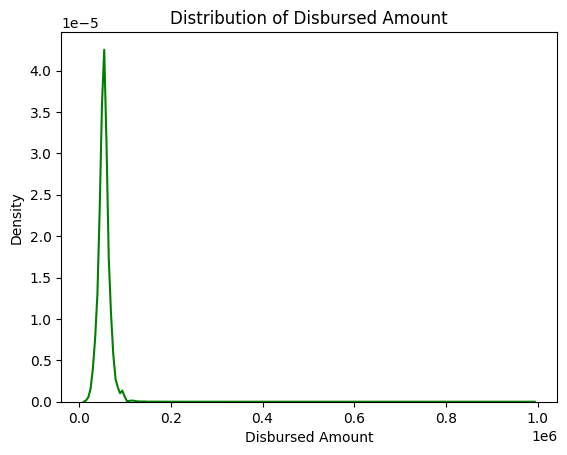

In [31]:
print(train.DISBURSED_AMOUNT.describe())
# plot_distribution('DISBURSED_AMOUNT','green')
sns.kdeplot(train.DISBURSED_AMOUNT, color='green')
plt.title('Distribution of Disbursed Amount')
plt.xlabel('Disbursed Amount')
plt.ylabel('Density')
plt.show()

### Outlier detection

##### Should we remove all the datapoints just because outlier is detected for one column, I mean that datapoint would be within the range according to other column's stat

In [32]:
import numpy as np

def counting_outlier(column):
    count = 0
    mean, std = np.mean(column).astype(float), np.std(column).astype(float)
    upper_limit = mean + 3 * std
    lower_limit = mean - 3 * std

    for i in range(len(column)):
        if column[i] > upper_limit or column[i] < lower_limit:
            count += 1
    return count

counting_outlier(train['DISBURSED_AMOUNT'])

3076

In [33]:
train.describe()

,UNIQUEID,DISBURSED_AMOUNT,ASSET_COST,LTV,BRANCH_ID,SUPPLIER_ID,MANUFACTURER_ID,CURRENT_PINCODE_ID,DATE_OF_BIRTH,DISBURSAL_DATE,...,SEC_SANCTIONED_AMOUNT,SEC_DISBURSED_AMOUNT,PRIMARY_INSTAL_AMT,SEC_INSTAL_AMT,NEW_ACCTS_IN_LAST_SIX_MONTHS,DELINQUENT_ACCTS_IN_LAST_SIX_MONTHS,AVERAGE_ACCT_AGE,CREDIT_HISTORY_LENGTH,NO_OF_INQUIRIES,LOAN_DEFAULT
count,233154.000000,233154.000000,2.331540e+05,233154.000000,233154.000000,233154.000000,233154.000000,233154.000000,233154,233154,...,2.331540e+05,2.331540e+05,2.331540e+05,2.331540e+05,233154.000000,233154.000000,233154.000000,233154.000000,233154.000000,233154.000000
mean,535917.573376,54356.993528,7.586507e+04,74.746530,72.936094,19638.635035,69.028054,3396.880247,1984-04-04 04:32:39.947502464,2018-09-23 09:57:53.079596032,...,7.295923e+03,7.179998e+03,1.310548e+04,3.232684e+02,0.381833,0.097481,8.915764,16.252404,0.206615,0.217071
min,417428.000000,13320.000000,3.700000e+04,10.030000,1.000000,10524.000000,45.000000,1.000000,1949-09-15 00:00:00,2018-08-01 00:00:00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,476786.250000,47145.000000,6.571700e+04,68.880000,14.000000,16535.000000,48.000000,1511.000000,1977-05-04 00:00:00,2018-08-30 00:00:00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,535978.500000,53803.000000,7.094600e+04,76.800000,61.000000,20333.000000,86.000000,2970.000000,1986-01-01 00:00:00,2018-09-25 00:00:00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,595039.750000,60413.000000,7.920175e+04,83.670000,130.000000,23000.000000,86.000000,5677.000000,1992-05-19 00:00:00,2018-10-21 00:00:00,...,0.000000e+00,0.000000e+00,1.999000e+03,0.000000e+00,0.000000,0.000000,13.000000,24.000000,0.000000,0.000000
max,671084.000000,990572.000000,1.628992e+06,95.000000,261.000000,24803.000000,156.000000,7345.000000,2000-10-20 00:00:00,2018-10-31 00:00:00,...,3.000000e+07,3.000000e+07,2.564281e+07,4.170901e+06,35.000000,20.000000,369.000000,468.000000,36.000000,1.000000
std,68315.693711,12971.314171,1.894478e+04,11.456636,69.834995,3491.949566,22.141304,2238.147502,NaN,NaN,...,1.831560e+05,1.825925e+05,1.513679e+05,1.555369e+04,0.955107,0.384439,15.106416,28.581255,0.706498,0.412252


In [34]:
train[['UNIQUEID','NO_OF_INQUIRIES', 'LOAN_DEFAULT']]

,UNIQUEID,NO_OF_INQUIRIES,LOAN_DEFAULT
0,420825,0,0
1,537409,0,1
2,417566,0,0
3,624493,1,1
4,539055,1,1
...,...,...,...
233149,626432,0,0
233150,606141,0,0
233151,613658,0,0
233152,548084,0,0


In [35]:
train.loc[train['NO_OF_INQUIRIES'] > 10]['LOAN_DEFAULT'].value_counts()

LOAN_DEFAULT
0    47
1    25
Name: count, dtype: int64

In [36]:
today = pd.to_datetime('today')
train['DATE_OF_BIRTH'] = today - train['DATE_OF_BIRTH']

train['DATE_OF_BIRTH'] = train['DATE_OF_BIRTH'].dt.days / 365.25
train['DATE_OF_BIRTH'].astype(int)

0         41
1         40
2         39
3         31
4         47
          ..
233149    37
233150    36
233151    49
233152    31
233153    41
Name: DATE_OF_BIRTH, Length: 233154, dtype: int64

In [37]:
train['DATE_OF_BIRTH'].astype(int)

0         41
1         40
2         39
3         31
4         47
          ..
233149    37
233150    36
233151    49
233152    31
233153    41
Name: DATE_OF_BIRTH, Length: 233154, dtype: int64

In [38]:
train.columns

Index(['UNIQUEID', 'DISBURSED_AMOUNT', 'ASSET_COST', 'LTV', 'BRANCH_ID',
       'SUPPLIER_ID', 'MANUFACTURER_ID', 'CURRENT_PINCODE_ID', 'DATE_OF_BIRTH',
       'EMPLOYMENT_TYPE', 'DISBURSAL_DATE', 'STATE_ID', 'EMPLOYEE_CODE_ID',
       'MOBILENO_AVL_FLAG', 'AADHAR_FLAG', 'PAN_FLAG', 'VOTERID_FLAG',
       'DRIVING_FLAG', 'PASSPORT_FLAG', 'PERFORM_CNS_SCORE',
       'PERFORM_CNS_SCORE_DESCRIPTION', 'PRI_NO_OF_ACCTS', 'PRI_ACTIVE_ACCTS',
       'PRI_OVERDUE_ACCTS', 'PRI_CURRENT_BALANCE', 'PRI_SANCTIONED_AMOUNT',
       'PRI_DISBURSED_AMOUNT', 'SEC_NO_OF_ACCTS', 'SEC_ACTIVE_ACCTS',
       'SEC_OVERDUE_ACCTS', 'SEC_CURRENT_BALANCE', 'SEC_SANCTIONED_AMOUNT',
       'SEC_DISBURSED_AMOUNT', 'PRIMARY_INSTAL_AMT', 'SEC_INSTAL_AMT',
       'NEW_ACCTS_IN_LAST_SIX_MONTHS', 'DELINQUENT_ACCTS_IN_LAST_SIX_MONTHS',
       'AVERAGE_ACCT_AGE', 'CREDIT_HISTORY_LENGTH', 'NO_OF_INQUIRIES',
       'LOAN_DEFAULT'],
      dtype='object')

In [39]:
train.groupby('PRI_NO_OF_ACCTS')['LOAN_DEFAULT'].value_counts()

PRI_NO_OF_ACCTS  LOAN_DEFAULT
0                0               89898
                 1               27052
1                0               27241
                 1                7737
2                0               15535
                                 ...  
148              1                   1
194              0                   1
271              0                   1
354              0                   1
453              1                   1
Name: count, Length: 179, dtype: int64

In [40]:
train.loc[train['PRI_NO_OF_ACCTS'] > train['PRI_NO_OF_ACCTS'].mean() + 3*train['PRI_NO_OF_ACCTS'].std()]['LOAN_DEFAULT'].value_counts()

LOAN_DEFAULT
0    3453
1     666
Name: count, dtype: int64

In [41]:
outlier_count = {}

for col in train.columns:
    if train[col].dtype == 'int64' or train[col].dtype == 'float64':
        outlier_count[col] = counting_outlier(train[col])


In [42]:
outlier_count

{'UNIQUEID': 0,
 'DISBURSED_AMOUNT': 3076,
 'ASSET_COST': 4425,
 'LTV': 2745,
 'BRANCH_ID': 0,
 'SUPPLIER_ID': 0,
 'MANUFACTURER_ID': 797,
 'CURRENT_PINCODE_ID': 0,
 'DATE_OF_BIRTH': 16,
 'STATE_ID': 232,
 'EMPLOYEE_CODE_ID': 0,
 'MOBILENO_AVL_FLAG': 0,
 'AADHAR_FLAG': 0,
 'PAN_FLAG': 17621,
 'VOTERID_FLAG': 0,
 'DRIVING_FLAG': 5419,
 'PASSPORT_FLAG': 496,
 'PERFORM_CNS_SCORE': 0,
 'PRI_NO_OF_ACCTS': 4119,
 'PRI_ACTIVE_ACCTS': 5476,
 'PRI_OVERDUE_ACCTS': 6305,
 'PRI_CURRENT_BALANCE': 2240,
 'PRI_SANCTIONED_AMOUNT': 617,
 'PRI_DISBURSED_AMOUNT': 616,
 'SEC_NO_OF_ACCTS': 2399,
 'SEC_ACTIVE_ACCTS': 3817,
 'SEC_OVERDUE_ACCTS': 1337,
 'SEC_CURRENT_BALANCE': 512,
 'SEC_SANCTIONED_AMOUNT': 632,
 'SEC_DISBURSED_AMOUNT': 623,
 'PRIMARY_INSTAL_AMT': 1271,
 'SEC_INSTAL_AMT': 242,
 'NEW_ACCTS_IN_LAST_SIX_MONTHS': 4088,
 'DELINQUENT_ACCTS_IN_LAST_SIX_MONTHS': 3254,
 'AVERAGE_ACCT_AGE': 4648,
 'CREDIT_HISTORY_LENGTH': 6064,
 'NO_OF_INQUIRIES': 3499,
 'LOAN_DEFAULT': 0}

In [43]:
_train = train.copy()
for col in train.columns:
    if train[col].dtype == 'int64' or train[col].dtype == 'float64':
        _capped_col = col + '_capped'
        lower_limit = _train[col].quantile(0.05)
        upper_limit = _train[col].quantile(0.95)
        _train[_capped_col] = _train[col].clip(lower=lower_limit, upper=upper_limit)

        _train.drop(col, axis=1, inplace=True)
_train.head()

,EMPLOYMENT_TYPE,DISBURSAL_DATE,PERFORM_CNS_SCORE_DESCRIPTION,UNIQUEID_capped,DISBURSED_AMOUNT_capped,ASSET_COST_capped,LTV_capped,BRANCH_ID_capped,SUPPLIER_ID_capped,MANUFACTURER_ID_capped,...,SEC_SANCTIONED_AMOUNT_capped,SEC_DISBURSED_AMOUNT_capped,PRIMARY_INSTAL_AMT_capped,SEC_INSTAL_AMT_capped,NEW_ACCTS_IN_LAST_SIX_MONTHS_capped,DELINQUENT_ACCTS_IN_LAST_SIX_MONTHS_capped,AVERAGE_ACCT_AGE_capped,CREDIT_HISTORY_LENGTH_capped,NO_OF_INQUIRIES_capped,LOAN_DEFAULT_capped
0,Salaried,2018-08-03,No Bureau History Available,429285.65,50578.0,58400,89.38,67,22807.0,45,...,0,0,0.0,0,0,0,0,0,0,0
1,Self employed,2018-09-26,I-Medium Risk,537409.00,47145.0,65550,73.23,67,22807.0,45,...,0,0,1991.0,0,0,1,23,23,0,1
2,Self employed,2018-08-01,No Bureau History Available,429285.65,53278.0,61360,89.38,67,22807.0,45,...,0,0,0.0,0,0,0,0,0,0,0
3,Self employed,2018-10-26,L-Very High Risk,624493.00,57513.0,66113,88.48,67,22807.0,45,...,0,0,31.0,0,0,0,8,15,1,1
4,Self employed,2018-09-26,No Bureau History Available,539055.00,52378.0,60300,88.39,67,22807.0,45,...,0,0,0.0,0,0,0,0,0,1,1


For linear model, I will go for _capped, for tree based and gradient boosting models, binning should be fine.

In [44]:
_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 233154 entries, 0 to 233153
Data columns (total 41 columns):
 #   Column                                      Non-Null Count   Dtype         
---  ------                                      --------------   -----         
 0   EMPLOYMENT_TYPE                             233154 non-null  object        
 1   DISBURSAL_DATE                              233154 non-null  datetime64[ns]
 2   PERFORM_CNS_SCORE_DESCRIPTION               233154 non-null  object        
 3   UNIQUEID_capped                             233154 non-null  float64       
 4   DISBURSED_AMOUNT_capped                     233154 non-null  float64       
 5   ASSET_COST_capped                           233154 non-null  int64         
 6   LTV_capped                                  233154 non-null  float64       
 7   BRANCH_ID_capped                            233154 non-null  int64         
 8   SUPPLIER_ID_capped                          233154 non-null  float64      

In [45]:
today = pd.to_datetime('today')
_train['DISBURSAL_DATE'] = today - _train['DISBURSAL_DATE']

_train['DISBURSAL_DATE'] = pd.to_timedelta(_train['DISBURSAL_DATE']).dt.days / 365.25

_train['DISBURSAL_DATE'].astype(int)

0         7
1         6
2         7
3         6
4         6
         ..
233149    6
233150    6
233151    6
233152    6
233153    6
Name: DISBURSAL_DATE, Length: 233154, dtype: int64

##### EMPLOYMENT_TYPE will be encoded and pd.get_dummies() for PERFORM_CNS_SCORE_DESCRIPTION

In [46]:
_ = pd.get_dummies(train['PERFORM_CNS_SCORE_DESCRIPTION'], prefix = 'PERFORM_CNS_SCORE_DESCRIPTION')
_train.drop('PERFORM_CNS_SCORE_DESCRIPTION', axis=1, inplace=True)
pd.concat([_train, _], axis=1)

,EMPLOYMENT_TYPE,DISBURSAL_DATE,UNIQUEID_capped,DISBURSED_AMOUNT_capped,ASSET_COST_capped,LTV_capped,BRANCH_ID_capped,SUPPLIER_ID_capped,MANUFACTURER_ID_capped,CURRENT_PINCODE_ID_capped,...,PERFORM_CNS_SCORE_DESCRIPTION_K-High Risk,PERFORM_CNS_SCORE_DESCRIPTION_L-Very High Risk,PERFORM_CNS_SCORE_DESCRIPTION_M-Very High Risk,PERFORM_CNS_SCORE_DESCRIPTION_No Bureau History Available,PERFORM_CNS_SCORE_DESCRIPTION_Not Scored: More than 50 active Accounts found,PERFORM_CNS_SCORE_DESCRIPTION_Not Scored: No Activity seen on the customer (Inactive),PERFORM_CNS_SCORE_DESCRIPTION_Not Scored: No Updates available in last 36 months,PERFORM_CNS_SCORE_DESCRIPTION_Not Scored: Not Enough Info available on the customer,PERFORM_CNS_SCORE_DESCRIPTION_Not Scored: Only a Guarantor,PERFORM_CNS_SCORE_DESCRIPTION_Not Scored: Sufficient History Not Available
0,Salaried,7.049966,429285.65,50578.00,58400,89.38,67,22807.0,45,1441,...,False,False,False,True,False,False,False,False,False,False
1,Self employed,6.902122,537409.00,47145.00,65550,73.23,67,22807.0,45,1502,...,False,False,False,False,False,False,False,False,False,False
2,Self employed,7.055441,429285.65,53278.00,61360,89.38,67,22807.0,45,1497,...,False,False,False,True,False,False,False,False,False,False
3,Self employed,6.819986,624493.00,57513.00,66113,88.48,67,22807.0,45,1501,...,False,True,False,False,False,False,False,False,False,False
4,Self employed,6.902122,539055.00,52378.00,60300,88.39,67,22807.0,45,1495,...,False,False,False,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
233149,Salaried,6.819986,626432.00,63213.00,105405,60.72,34,20700.0,48,1050,...,False,False,False,False,False,False,False,False,False,False
233150,Self employed,6.828200,606141.00,73651.00,100600,74.95,34,23775.0,51,990,...,False,False,False,False,False,False,False,False,False,False
233151,Salaried,6.825462,613658.00,34939.00,71212,52.31,77,22186.0,86,2299,...,False,False,False,True,False,False,False,False,False,False
233152,Salaried,6.893908,548084.00,34939.00,73286,52.31,77,22186.0,86,2299,...,False,False,False,True,False,False,False,False,False,False


In [47]:
employment_dummies = pd.get_dummies(train['EMPLOYMENT_TYPE'], prefix = 'EMPLOYMENT_TYPE')
_train.drop('EMPLOYMENT_TYPE', axis=1, inplace=True)
pd.concat([_train, employment_dummies], axis=1)

,DISBURSAL_DATE,UNIQUEID_capped,DISBURSED_AMOUNT_capped,ASSET_COST_capped,LTV_capped,BRANCH_ID_capped,SUPPLIER_ID_capped,MANUFACTURER_ID_capped,CURRENT_PINCODE_ID_capped,DATE_OF_BIRTH_capped,...,SEC_INSTAL_AMT_capped,NEW_ACCTS_IN_LAST_SIX_MONTHS_capped,DELINQUENT_ACCTS_IN_LAST_SIX_MONTHS_capped,AVERAGE_ACCT_AGE_capped,CREDIT_HISTORY_LENGTH_capped,NO_OF_INQUIRIES_capped,LOAN_DEFAULT_capped,EMPLOYMENT_TYPE_Missing,EMPLOYMENT_TYPE_Salaried,EMPLOYMENT_TYPE_Self employed
0,7.049966,429285.65,50578.00,58400,89.38,67,22807.0,45,1441,41.637235,...,0,0,0,0,0,0,0,False,True,False
1,6.902122,537409.00,47145.00,65550,73.23,67,22807.0,45,1502,40.057495,...,0,0,1,23,23,0,1,False,False,True
2,7.055441,429285.65,53278.00,61360,89.38,67,22807.0,45,1497,39.991786,...,0,0,0,0,0,0,0,False,False,True
3,6.819986,624493.00,57513.00,66113,88.48,67,22807.0,45,1501,31.641342,...,0,0,0,8,15,1,1,False,False,True
4,6.902122,539055.00,52378.00,60300,88.39,67,22807.0,45,1495,47.698836,...,0,0,0,0,0,1,1,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
233149,6.819986,626432.00,63213.00,105405,60.72,34,20700.0,48,1050,37.054073,...,0,0,0,21,39,0,0,False,True,False
233150,6.828200,606141.00,73651.00,100600,74.95,34,23775.0,51,990,36.709103,...,0,0,0,6,6,0,0,False,False,True
233151,6.825462,613658.00,34939.00,71212,52.31,77,22186.0,86,2299,49.221081,...,0,0,0,0,0,0,0,False,True,False
233152,6.893908,548084.00,34939.00,73286,52.31,77,22186.0,86,2299,31.405886,...,0,0,0,0,0,0,0,False,True,False


In [48]:
_train = pd.concat([_train, _, employment_dummies], axis=1)

In [49]:
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression


k_fold = KFold(n_splits=5, shuffle=True, random_state=42)

In [50]:
_train.columns

Index(['DISBURSAL_DATE', 'UNIQUEID_capped', 'DISBURSED_AMOUNT_capped',
       'ASSET_COST_capped', 'LTV_capped', 'BRANCH_ID_capped',
       'SUPPLIER_ID_capped', 'MANUFACTURER_ID_capped',
       'CURRENT_PINCODE_ID_capped', 'DATE_OF_BIRTH_capped', 'STATE_ID_capped',
       'EMPLOYEE_CODE_ID_capped', 'MOBILENO_AVL_FLAG_capped',
       'AADHAR_FLAG_capped', 'PAN_FLAG_capped', 'VOTERID_FLAG_capped',
       'DRIVING_FLAG_capped', 'PASSPORT_FLAG_capped',
       'PERFORM_CNS_SCORE_capped', 'PRI_NO_OF_ACCTS_capped',
       'PRI_ACTIVE_ACCTS_capped', 'PRI_OVERDUE_ACCTS_capped',
       'PRI_CURRENT_BALANCE_capped', 'PRI_SANCTIONED_AMOUNT_capped',
       'PRI_DISBURSED_AMOUNT_capped', 'SEC_NO_OF_ACCTS_capped',
       'SEC_ACTIVE_ACCTS_capped', 'SEC_OVERDUE_ACCTS_capped',
       'SEC_CURRENT_BALANCE_capped', 'SEC_SANCTIONED_AMOUNT_capped',
       'SEC_DISBURSED_AMOUNT_capped', 'PRIMARY_INSTAL_AMT_capped',
       'SEC_INSTAL_AMT_capped', 'NEW_ACCTS_IN_LAST_SIX_MONTHS_capped',
       'DELINQUENT_AC

In [51]:
y = _train['LOAN_DEFAULT_capped']
X = _train.drop('LOAN_DEFAULT_capped', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((186523, 61), (46631, 61), (186523,), (46631,))

In [52]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

roc_auc_score(y_test, lr.predict_proba(X_test)[:, 1])

c:\FraudDetection_Training_Project\fenv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning:

lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



0.5780846148413589

In [53]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(max_depth=3)
dt.fit(X_train, y_train)

roc_auc_score(y_test, dt.predict_proba(X_test)[:, 1])

0.5971147921536804

In [55]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(max_depth=3)
rfc.fit(X_train, y_train)

roc_auc_score(y_test, rfc.predict_proba(X_test)[:, 1])

0.6262810632210987

In [58]:
from xgboost import XGBClassifier
xgbc = XGBClassifier(max_depth=3)
xgbc.fit(X_train, y_train)

roc_auc_score(y_test, xgbc.predict_proba(X_test)[:, 1])

0.6643535105878234

In [ ]:
import re
df = df.rename(columns = lambda x:re.sub('[^A-Za-z0-9_]+', '', x))

In [68]:
import re
train_lgbm = _train.copy()
train_lgbm = train_lgbm.rename(columns = lambda x:re.sub('[^A-Za-z0-9_]+', '', x))
y_lgmb, X_lgbm = train_lgbm['LOAN_DEFAULT_capped'], train_lgbm.drop('LOAN_DEFAULT_capped', axis=1)
X_lgbm_train, X_lgbm_test, y_lgbm_train, y_lgbm_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [70]:
train_lgbm = train_lgbm.rename(columns = lambda x:re.sub('[^A-Za-z0-9_]+', '', x))
train_lgbm.columns

Index(['DISBURSAL_DATE', 'UNIQUEID_capped', 'DISBURSED_AMOUNT_capped',
       'ASSET_COST_capped', 'LTV_capped', 'BRANCH_ID_capped',
       'SUPPLIER_ID_capped', 'MANUFACTURER_ID_capped',
       'CURRENT_PINCODE_ID_capped', 'DATE_OF_BIRTH_capped', 'STATE_ID_capped',
       'EMPLOYEE_CODE_ID_capped', 'MOBILENO_AVL_FLAG_capped',
       'AADHAR_FLAG_capped', 'PAN_FLAG_capped', 'VOTERID_FLAG_capped',
       'DRIVING_FLAG_capped', 'PASSPORT_FLAG_capped',
       'PERFORM_CNS_SCORE_capped', 'PRI_NO_OF_ACCTS_capped',
       'PRI_ACTIVE_ACCTS_capped', 'PRI_OVERDUE_ACCTS_capped',
       'PRI_CURRENT_BALANCE_capped', 'PRI_SANCTIONED_AMOUNT_capped',
       'PRI_DISBURSED_AMOUNT_capped', 'SEC_NO_OF_ACCTS_capped',
       'SEC_ACTIVE_ACCTS_capped', 'SEC_OVERDUE_ACCTS_capped',
       'SEC_CURRENT_BALANCE_capped', 'SEC_SANCTIONED_AMOUNT_capped',
       'SEC_DISBURSED_AMOUNT_capped', 'PRIMARY_INSTAL_AMT_capped',
       'SEC_INSTAL_AMT_capped', 'NEW_ACCTS_IN_LAST_SIX_MONTHS_capped',
       'DELINQUENT_AC

In [71]:
new_columns = {col: re.sub(r'[^A-Za-z0-9_]+', '', col) for col in _train.columns}

_train = _train.rename(columns=new_columns)
X_lgbm, y_lgbm = _train.drop('LOAN_DEFAULT_capped', axis=1), _train['LOAN_DEFAULT_capped']
# lgbm.fit(_train, y_train)
X_train, X_test, y_train, y_test = train_test_split(X_lgbm, y_lgbm, test_size=0.2, random_state=42)
lgbm.fit(X_train, y_train)
roc_auc_score(y_test, lgbm.predict_proba(X_test)[:, 1])

[LightGBM] [Info] Number of positive: 40457, number of negative: 146066
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011384 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3660
[LightGBM] [Info] Number of data points in the train set: 186523, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.216901 -> initscore=-1.283819
[LightGBM] [Info] Start training from score -1.283819


0.6653330942431641

In [72]:
from sklearn.metrics import precision_score, balanced_accuracy_score, f1_score, recall_score

print(precision_score(y_test, lgbm.predict(X_test)))
print(balanced_accuracy_score(y_test, lgbm.predict(X_test)))
print(f1_score(y_test, lgbm.predict(X_test)))
print(recall_score(y_test, lgbm.predict(X_test)))

0.5603112840466926
0.50554188041648
0.02766304869849198
0.014181603309040771


In [69]:
lgbm.fit(X_lgbm_train, y_lgbm_train)

roc_auc_score(y_lgbm_test, lgbm.predict_proba(X_lgbm_test)[:, 1])

LightGBMError: Do not support special JSON characters in feature name.

In [67]:
train_lgbm.columns

Index(['DISBURSAL_DATE', 'UNIQUEID_capped', 'DISBURSED_AMOUNT_capped',
       'ASSET_COST_capped', 'LTV_capped', 'BRANCH_ID_capped',
       'SUPPLIER_ID_capped', 'MANUFACTURER_ID_capped',
       'CURRENT_PINCODE_ID_capped', 'DATE_OF_BIRTH_capped', 'STATE_ID_capped',
       'EMPLOYEE_CODE_ID_capped', 'MOBILENO_AVL_FLAG_capped',
       'AADHAR_FLAG_capped', 'PAN_FLAG_capped', 'VOTERID_FLAG_capped',
       'DRIVING_FLAG_capped', 'PASSPORT_FLAG_capped',
       'PERFORM_CNS_SCORE_capped', 'PRI_NO_OF_ACCTS_capped',
       'PRI_ACTIVE_ACCTS_capped', 'PRI_OVERDUE_ACCTS_capped',
       'PRI_CURRENT_BALANCE_capped', 'PRI_SANCTIONED_AMOUNT_capped',
       'PRI_DISBURSED_AMOUNT_capped', 'SEC_NO_OF_ACCTS_capped',
       'SEC_ACTIVE_ACCTS_capped', 'SEC_OVERDUE_ACCTS_capped',
       'SEC_CURRENT_BALANCE_capped', 'SEC_SANCTIONED_AMOUNT_capped',
       'SEC_DISBURSED_AMOUNT_capped', 'PRIMARY_INSTAL_AMT_capped',
       'SEC_INSTAL_AMT_capped', 'NEW_ACCTS_IN_LAST_SIX_MONTHS_capped',
       'DELINQUENT_AC

In [59]:
from lightgbm import LGBMClassifier
lgbm = LGBMClassifier()
lgbm.fit(X_train, y_train)

roc_auc_score(y_test, lgbm.predict_proba(X_test)[:, 1])

LightGBMError: Do not support special JSON characters in feature name.

In [ ]:
_cbc = CatBoostClassifier()

In [73]:
from catboost import CatBoostClassifier
cbc = CatBoostClassifier()
cbc.fit(X_train, y_train)

roc_auc_score(y_test, cbc.predict_proba(X_test)[:, 1])

Learning rate set to 0.096059
0:	learn: 0.6576211	total: 33.1ms	remaining: 33.1s
1:	learn: 0.6284029	total: 69.4ms	remaining: 34.6s
2:	learn: 0.6048514	total: 105ms	remaining: 34.8s
3:	learn: 0.5861460	total: 138ms	remaining: 34.3s
4:	learn: 0.5715121	total: 178ms	remaining: 35.4s
5:	learn: 0.5592673	total: 217ms	remaining: 36s
6:	learn: 0.5491813	total: 253ms	remaining: 35.8s
7:	learn: 0.5412789	total: 286ms	remaining: 35.4s
8:	learn: 0.5346854	total: 317ms	remaining: 34.9s
9:	learn: 0.5293036	total: 347ms	remaining: 34.3s
10:	learn: 0.5249428	total: 380ms	remaining: 34.1s
11:	learn: 0.5214038	total: 412ms	remaining: 33.9s
12:	learn: 0.5183461	total: 449ms	remaining: 34.1s
13:	learn: 0.5157895	total: 482ms	remaining: 33.9s
14:	learn: 0.5135515	total: 515ms	remaining: 33.8s
15:	learn: 0.5116305	total: 563ms	remaining: 34.6s
16:	learn: 0.5100343	total: 596ms	remaining: 34.4s
17:	learn: 0.5087517	total: 625ms	remaining: 34.1s
18:	learn: 0.5075469	total: 659ms	remaining: 34s
19:	learn: 0.

0.6689750574653638

In [74]:
print(f"Precision: {precision_score(y_test, cbc.predict(X_test))}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, cbc.predict(X_test))}")
print(f"F1 Score: {f1_score(y_test, cbc.predict(X_test))}")
print(f"Recall: {recall_score(y_test, cbc.predict(X_test))}")

Precision: 0.5163584637268848
Balanced Accuracy: 0.5132142581890556
F1 Score: 0.0668693009118541
Recall: 0.03574945834154028


In [57]:
test.columns

Index(['UNIQUEID', 'DISBURSED_AMOUNT', 'ASSET_COST', 'LTV', 'BRANCH_ID',
       'SUPPLIER_ID', 'MANUFACTURER_ID', 'CURRENT_PINCODE_ID', 'DATE_OF_BIRTH',
       'EMPLOYMENT_TYPE', 'DISBURSAL_DATE', 'STATE_ID', 'EMPLOYEE_CODE_ID',
       'MOBILENO_AVL_FLAG', 'AADHAR_FLAG', 'PAN_FLAG', 'VOTERID_FLAG',
       'DRIVING_FLAG', 'PASSPORT_FLAG', 'PERFORM_CNS_SCORE',
       'PERFORM_CNS_SCORE_DESCRIPTION', 'PRI_NO_OF_ACCTS', 'PRI_ACTIVE_ACCTS',
       'PRI_OVERDUE_ACCTS', 'PRI_CURRENT_BALANCE', 'PRI_SANCTIONED_AMOUNT',
       'PRI_DISBURSED_AMOUNT', 'SEC_NO_OF_ACCTS', 'SEC_ACTIVE_ACCTS',
       'SEC_OVERDUE_ACCTS', 'SEC_CURRENT_BALANCE', 'SEC_SANCTIONED_AMOUNT',
       'SEC_DISBURSED_AMOUNT', 'PRIMARY_INSTAL_AMT', 'SEC_INSTAL_AMT',
       'NEW_ACCTS_IN_LAST_SIX_MONTHS', 'DELINQUENT_ACCTS_IN_LAST_SIX_MONTHS',
       'AVERAGE_ACCT_AGE', 'CREDIT_HISTORY_LENGTH', 'NO_OF_INQUIRIES'],
      dtype='object')

In [78]:
# from sklearn.datasets import make_classification
# # We generate both features and labels.
# X_synthetic, y_synthetic = make_classification(
#     n_samples=6,          # Number of new samples to create
#     n_features=X_train.shape[1], # Match the number of features in your original data
#     n_classes=2,
#     weights=[0.1, 0.9],   # Heavily weighted toward the minority class
#     n_informative=5,      # Ensure the features have predictive power
#     random_state=42
# )

# # Filter to keep only the new minority class samples
# # This makes sure we are only adding defaulted loan examples
# X_synthetic_minority = X_synthetic[y_synthetic == 1]
# y_synthetic_minority = y_synthetic[y_synthetic == 1]


# # --- Step 2: Convert synthetic data to a DataFrame ---
# # Ensure the new data has the same column names as your original data.
# X_synthetic_df = pd.DataFrame(X_synthetic_minority, columns=X_train.columns)
# y_synthetic_s = pd.Series(y_synthetic_minority, name='LOAN_DEFAULT')

### How to deal with Imbalanced Class

In [ ]:
from sklearn.datasets import make_classification


#### TBD: SMOTE, downsampling and Upsampling 

In [54]:
# import torch
# def compute_map(eval_preds):
#     labels, logits = eval_preds

#     probs = torch.nn.functional.softmax(logits, dim=-1)